In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA, TruncatedSVD
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
import numpy as np

In [3]:
df_encoded = pd.read_csv("water_quality_cleaned.csv")
df_encoded.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
df_encoded.info()
df_encoded.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7986 non-null   float64
 1   ammonia      7986 non-null   float64
 2   arsenic      7986 non-null   float64
 3   barium       7986 non-null   float64
 4   cadmium      7986 non-null   float64
 5   chloramine   7986 non-null   float64
 6   chromium     7986 non-null   float64
 7   copper       7986 non-null   float64
 8   flouride     7986 non-null   float64
 9   bacteria     7986 non-null   float64
 10  viruses      7986 non-null   float64
 11  lead         7986 non-null   float64
 12  nitrates     7986 non-null   float64
 13  nitrites     7986 non-null   float64
 14  mercury      7986 non-null   float64
 15  perchlorate  7986 non-null   float64
 16  radium       7986 non-null   float64
 17  selenium     7986 non-null   float64
 18  silver       7986 non-null   float64
 19  uraniu

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
count,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,...,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000,7986.000000
mean,0.665681,14.296141,0.161008,1.566062,0.042744,2.176069,0.247029,0.806018,0.771726,0.319500,...,0.099479,9.816521,1.329284,0.005190,16.463139,2.917437,0.049691,0.147646,0.044668,0.113949
std,1.265231,8.870009,0.252244,1.214996,0.036022,2.567149,0.270617,0.653397,0.435538,0.329427,...,0.058138,5.542970,0.573313,0.002967,17.694342,2.322175,0.028781,0.143522,0.026902,0.317770
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040000,6.600000,0.030000,0.560000,0.008000,0.100000,0.050000,0.090000,0.402500,0.000000,...,0.048000,5.000000,1.000000,0.003000,2.170000,0.820000,0.020000,0.040000,0.020000,0.000000
50%,0.070000,14.150000,0.050000,1.190000,0.040000,0.530000,0.090000,0.750000,0.770000,0.220000,...,0.102000,9.925000,1.420000,0.005000,7.740000,2.410000,0.050000,0.080000,0.050000,0.000000
75%,0.280000,22.150000,0.100000,2.480000,0.070000,4.240000,0.440000,1.390000,1.160000,0.610000,...,0.151000,14.610000,1.760000,0.008000,29.502500,4.670000,0.070000,0.240000,0.070000,0.000000
max,5.050000,29.840000,1.050000,4.940000,0.130000,8.680000,0.900000,2.000000,1.500000,1.000000,...,0.200000,19.830000,2.930000,0.010000,60.010000,7.990000,0.100000,0.500000,0.090000,1.000000


Separate features and labels

In [5]:
X = df_encoded.drop(columns=["is_safe"])  # bỏ cột label
y = df_encoded["is_safe"]                 # nhãn đã mã hóa số

TRY NOT TO USE Standardization of features (MinMaxScaler)

Split the data into train and test sets (NOT USE STANDARDIZATION)

In [6]:
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

FIX dataset bị mất cân bằng (imbalanced dataset)

In [7]:
# SMOTE trên dữ liệu gốc (chưa normalize)
smote0 = SMOTE(random_state=42)
X_train_smote0, y_train_smote0 = smote0.fit_resample(X_train0, y_train0)

K-NN (NOT USE STANDARDIZATION)

In [8]:
knn0 = KNeighborsClassifier(n_neighbors=2)  # chọn k=2 làm ví dụ
knn0.fit(X_train_smote0, y_train_smote0)

y_pred0 = knn0.predict(X_test0)

In [9]:
# Tính accuracy
accuracy0 = accuracy_score(y_test0, y_pred0)
print(f"Accuracy: {accuracy0:}")

# Tính classification error
classification_error0 = 1 - accuracy0
print(f"Classification error: {classification_error0:}")

# In báo cáo phân loại chi tiết (precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_test0, y_pred0))

Accuracy: 0.7942404006677797
Classification error: 0.20575959933222032
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      2123
           1       0.18      0.22      0.20       273

    accuracy                           0.79      2396
   macro avg       0.54      0.54      0.54      2396
weighted avg       0.81      0.79      0.80      2396



Vary the value of k (NOT USE STANDARDIZATION)

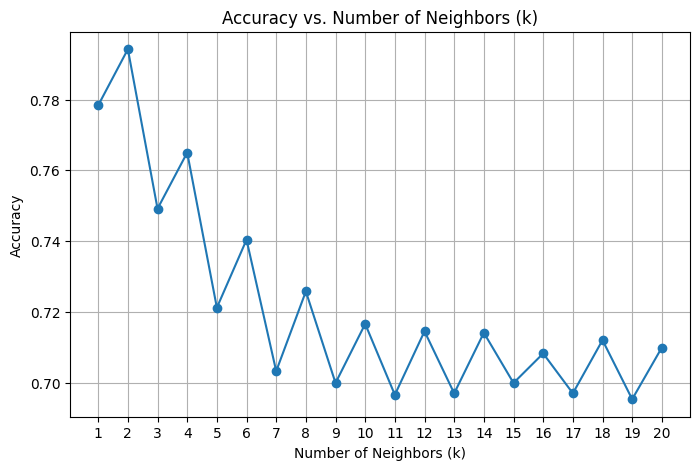

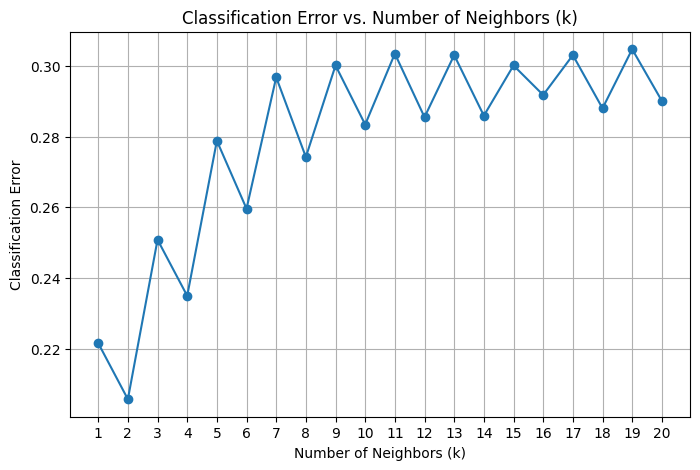

In [10]:
k_values0 = range(1, 21)
errors0 = []
accuracies0 = []

for k in k_values0:
    knn0 = KNeighborsClassifier(n_neighbors=k)
    knn0.fit(X_train_smote0, y_train_smote0)
    y_pred0 = knn0.predict(X_test0)
    acc0 = accuracy_score(y_test0, y_pred0)
    accuracies0.append(acc0)
    errors0.append(1 - acc0)


# Vẽ accuracy
plt.figure(figsize=(8,5))
plt.plot(k_values0, accuracies0, marker='o')
plt.title('Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values0)
plt.grid(True)

plt.savefig("acc_0_norm", dpi = 300)

plt.show()

# Vẽ classification error
plt.figure(figsize=(8,5))
plt.plot(k_values0, errors0, marker='o')
plt.title('Classification Error vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Classification Error')
plt.xticks(k_values0)
plt.grid(True)

plt.savefig("err_0_norm", dpi = 300)

plt.show()

In [11]:

k = 2  # số láng giềng

# Giả sử bạn đã có các biến: X_train_smote0, y_train_smote0, X_test0, y_test0
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_train_smote0)  # Dữ liệu train đã áp dụng SMOTE, chưa normalize

distances, indices = nn.kneighbors(X_test0)  # Dữ liệu test chưa normalize

tie_points = 0
total_points = len(X_test0)

for i, neighbors_idx in enumerate(indices):
    neighbor_labels = y_train_smote0.iloc[neighbors_idx].values  # lấy nhãn theo vị trí
    label_counts = Counter(neighbor_labels)
    most_common = label_counts.most_common()

    max_count = most_common[0][1]
    tied_classes = [label for label, count in most_common if count == max_count]

    if len(tied_classes) > 1:
        tie_points += 1
        print(f"Point {i} has tie between classes {tied_classes} with {max_count} votes each.")

print(f"Total points with tie: {tie_points} out of {total_points}")
print(f"Percentage of tie points: {tie_points / total_points * 100:.2f}%")


Point 3 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 12 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 14 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 26 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 29 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 45 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 47 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 50 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 57 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 63 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 73 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 88 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 89 has tie between classes [np.int64(0), np.int

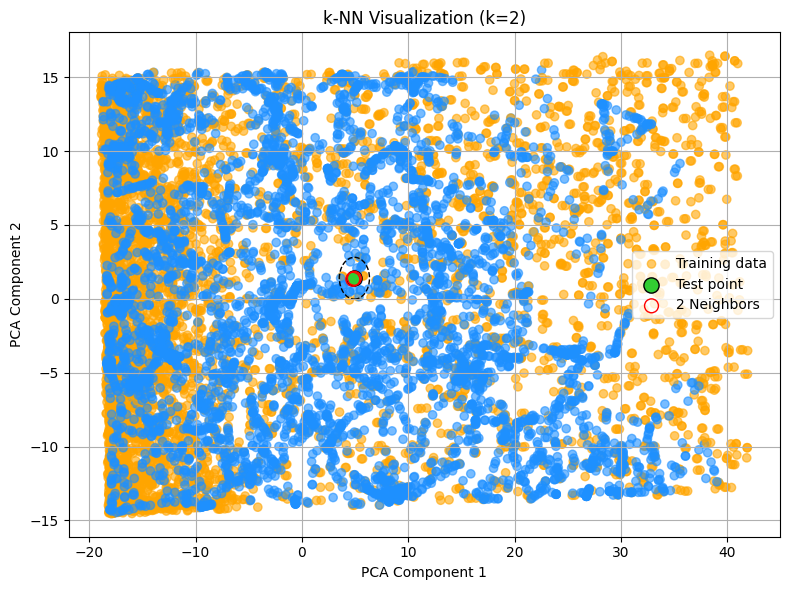

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.neighbors import KNeighborsClassifier

# Giảm chiều dữ liệu test/train về 2D để vẽ
pca = PCA(n_components=2)
X_train_vis = pca.fit_transform(X_train_smote0)
X_test_vis = pca.transform(X_test0)

# Chọn một điểm test để minh họa
index = 5  # bạn có thể thử các chỉ số khác
x_sample = X_test0.iloc[index:index+1]
x_sample_vis = X_test_vis[index]
y_sample_true = y_test0.iloc[index]

# Huấn luyện KNN để tìm hàng xóm
k_viz = 2
knn_viz = KNeighborsClassifier(n_neighbors=k_viz)
knn_viz.fit(X_train_smote0, y_train_smote0)

# Tìm k hàng xóm gần nhất
distances, indices = knn_viz.kneighbors(x_sample, n_neighbors=k_viz)
neighbors_vis = X_train_vis[indices[0]]

# Tạo màu cho tập train
colors = ['dodgerblue' if label == 1 else 'orange' for label in y_train_smote0]

# Vẽ tập huấn luyện
plt.figure(figsize=(8, 6))
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=colors, alpha=0.6, label='Training data')

# Vẽ điểm test
plt.scatter(x_sample_vis[0], x_sample_vis[1], color='limegreen', s=120, label='Test point', edgecolors='black')

# Vẽ k hàng xóm
plt.scatter(neighbors_vis[:, 0], neighbors_vis[:, 1], facecolors='none', edgecolors='red', s=100, label=f'{k_viz} Neighbors')

# Vẽ đường tròn bao quanh hàng xóm
radius = np.linalg.norm(x_sample.values - X_train_smote0.iloc[indices[0][-1]].values)
circle = Circle(xy=x_sample_vis, radius=radius, edgecolor='black', facecolor='none', linestyle='--')
plt.gca().add_patch(circle)

plt.title(f'k-NN Visualization (k={k_viz})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


-------------------

USING STANDARDIZATION TO K-NN

Split the data into train and test sets

In [13]:

# 1. Chia dữ liệu gốc trước
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


Standardization of features (MinMaxScaler)

In [14]:

# 2. Chuẩn hóa riêng tập train
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Chuẩn hóa tập test theo scaler đã fit trên train
X_test_scaled = scaler.transform(X_test)


FIX dataset bị mất cân bằng (imbalanced dataset)

In [15]:
# 4. SMOTE trên tập train đã chuẩn hóa
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

K-NN

Step-by-step answer:

Prepare the data:
Ensure your features are scaled and your labels are encoded as numbers.

Split the data:
Use train-test split to separate the dataset into training and testing subsets.

Train the K-NN model:
Choose a value for k (e.g., 6), train the model on the training data.

Predict on test data:
Use the trained model to predict labels on the test set.

Calculate classification error:
Classification error = 1 - accuracy, where accuracy is the proportion of correct predictions.

Bạn chạy thuật toán K-NN trên dataset đã chia thành train và test, dùng các đặc trưng đã chuẩn hóa và nhãn đã mã hóa. Sau khi huấn luyện mô hình, bạn dự đoán nhãn trên tập test và so sánh với nhãn thật. Classification error được tính bằng:

classification error = 1 − accuracy


In [16]:
# 5. Huấn luyện KNN với k=2 (ví dụ)
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_smote, y_train_smote)

y_pred = knn.predict(X_test_scaled)


In [146]:
# Tính accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:}")

# Tính classification error
classification_error = 1 - accuracy
print(f"Classification error: {classification_error:}")

# In báo cáo phân loại chi tiết (precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.828881469115192
Classification error: 0.171118530884808
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2123
           1       0.30      0.38      0.33       273

    accuracy                           0.83      2396
   macro avg       0.61      0.63      0.62      2396
weighted avg       0.85      0.83      0.84      2396



Vary the value of k

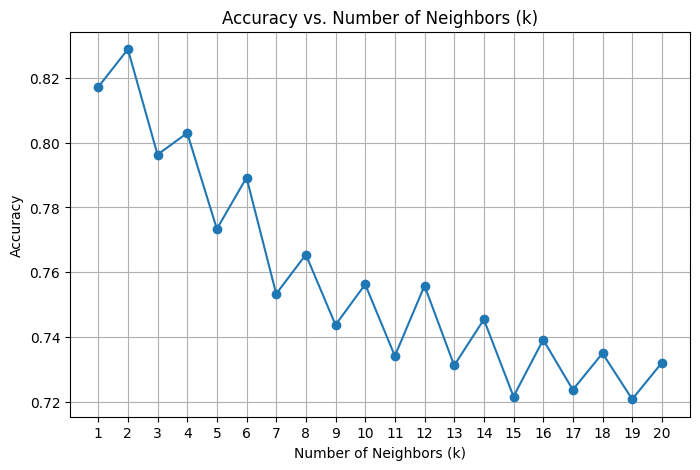

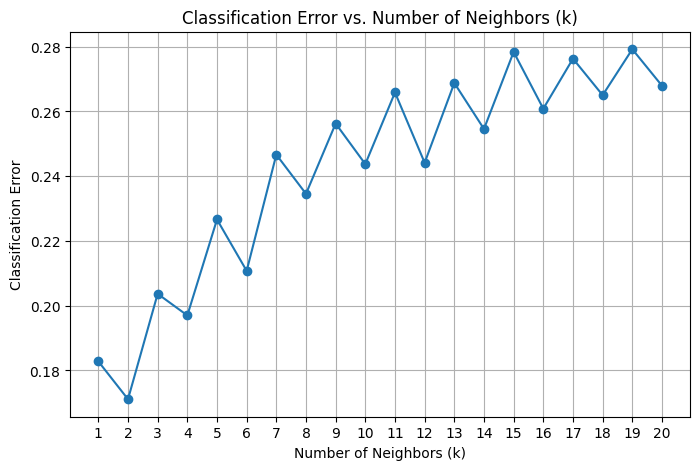

In [17]:

k_values = range(1, 21)
accuracies = []
errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    errors.append(1 - acc)

# Vẽ biểu đồ Accuracy
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)

plt.savefig("acc_norm", dpi = 300)

plt.show()

# Vẽ biểu đồ Classification Error
plt.figure(figsize=(8,5))
plt.plot(k_values, errors, marker='o')
plt.title('Classification Error vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Classification Error')
plt.xticks(k_values)
plt.grid(True)

plt.savefig("err_norm", dpi = 300)

plt.show()


In [19]:

k = 2  # số láng giềng

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_train_smote)

distances, indices = nn.kneighbors(X_test_scaled)

tie_points = 0
total_points = len(X_test_scaled)

for i, neighbors_idx in enumerate(indices):
    neighbor_labels = y_train_smote.iloc[neighbors_idx].values  # dùng iloc để lấy nhãn theo vị trí
    label_counts = Counter(neighbor_labels)
    most_common = label_counts.most_common()

    max_count = most_common[0][1]
    tied_classes = [label for label, count in most_common if count == max_count]

    if len(tied_classes) > 1:
        tie_points += 1
        print(f"Point {i} has tie between classes {tied_classes} with {max_count} votes each.")

print(f"Total points with tie: {tie_points} out of {total_points}")
print(f"Percentage of tie points: {tie_points/total_points*100:.2f}%")



Point 0 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 11 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 17 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 31 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 37 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 48 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 49 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 59 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 63 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 65 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 70 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 83 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 90 has tie between classes [np.int64(0), np.int

PCA & SVD

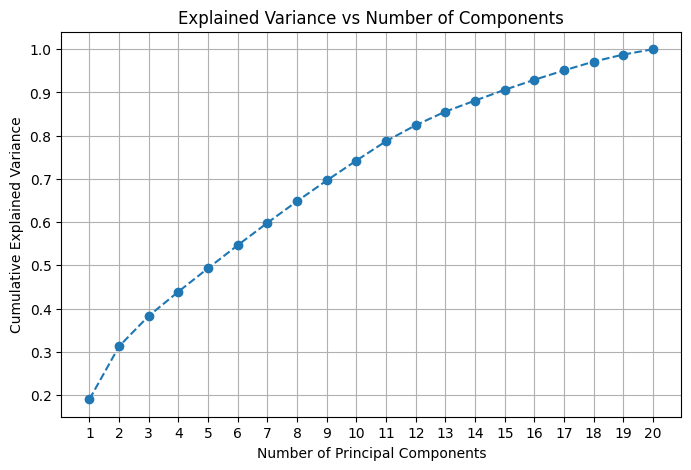

In [20]:
pca = PCA().fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o', linestyle='--')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))  # fix số nguyên
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()


In [21]:
# 3. Giảm chiều PCA và SVD trên dữ liệu đã chuẩn hóa
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [22]:
# Fit SVD with many components first (ví dụ toàn bộ)
svd_full = TruncatedSVD(n_components=X_train_scaled.shape[1], random_state=42)
svd_full.fit(X_train_scaled)

# Tính tổng phương sai tích lũy
cumulative_variance = svd_full.explained_variance_ratio_.cumsum()

# Tìm số lượng thành phần để đạt ≥ 95%
n_components_95 = (cumulative_variance >= 0.95).argmax() + 1
print(f"Number of components to retain ≥95% variance: {n_components_95}")


svd = TruncatedSVD(n_components=n_components_95, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)


Number of components to retain ≥95% variance: 18


In [23]:
# 4. Áp dụng SMOTE chỉ trên tập train đã giảm chiều
smote = SMOTE(random_state=42)
X_train_pca_smote, y_train_pca_smote = smote.fit_resample(X_train_pca, y_train)
X_train_svd_smote, y_train_svd_smote = smote.fit_resample(X_train_svd, y_train)

In [24]:
# Train KNN
knn_pca = KNeighborsClassifier(n_neighbors=2)
knn_pca.fit(X_train_pca_smote, y_train_pca_smote)
y_pred_pca = knn_pca.predict(X_test_pca)

knn_svd = KNeighborsClassifier(n_neighbors=2)
knn_svd.fit(X_train_svd_smote, y_train_svd_smote)
y_pred_svd = knn_svd.predict(X_test_svd)

In [25]:
# For PCA
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA Accuracy: {accuracy_pca:}")

classification_error_pca = 1 - accuracy_pca
print(f"PCA Classification Error: {classification_error_pca:}")

print("PCA Classification Report:")
print(classification_report(y_test, y_pred_pca))

# For SVD
accuracy_svd = accuracy_score(y_test, y_pred_svd)
print(f"SVD Accuracy: {accuracy_svd:}")

classification_error_svd = 1 - accuracy_svd
print(f"SVD Classification Error: {classification_error_svd:}")

print("SVD Classification Report:")
print(classification_report(y_test, y_pred_svd))


PCA Accuracy: 0.827212020033389
PCA Classification Error: 0.172787979966611
PCA Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2123
           1       0.29      0.37      0.33       273

    accuracy                           0.83      2396
   macro avg       0.60      0.63      0.61      2396
weighted avg       0.84      0.83      0.84      2396

SVD Accuracy: 0.8284641068447413
SVD Classification Error: 0.17153589315525875
SVD Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2123
           1       0.30      0.37      0.33       273

    accuracy                           0.83      2396
   macro avg       0.61      0.63      0.61      2396
weighted avg       0.85      0.83      0.84      2396



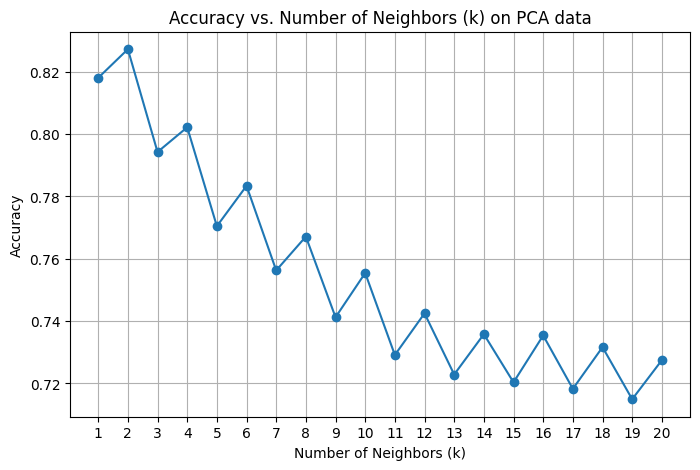

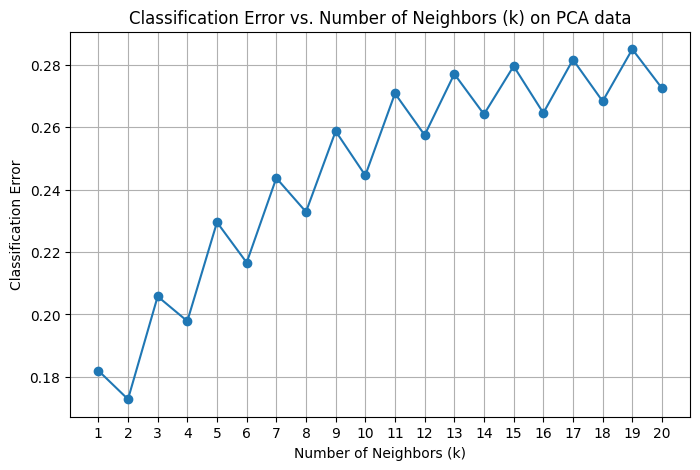

In [26]:
k_values_pca = range(1, 21)
accuracies_pca = []
errors_pca = []

for k in k_values_pca:
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca_smote, y_train_pca_smote)  # Dùng dữ liệu đã SMOTE
    y_pred = knn_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred)
    accuracies_pca.append(acc_pca)
    errors_pca.append(1 - acc_pca)

# Vẽ biểu đồ Accuracy
plt.figure(figsize=(8,5))
plt.plot(k_values_pca, accuracies_pca, marker='o')
plt.title('Accuracy vs. Number of Neighbors (k) on PCA data')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values_pca)
plt.grid(True)
plt.show()

# Vẽ biểu đồ Classification Error
plt.figure(figsize=(8,5))
plt.plot(k_values_pca, errors_pca, marker='o')
plt.title('Classification Error vs. Number of Neighbors (k) on PCA data')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Classification Error')
plt.xticks(k_values_pca)
plt.grid(True)
plt.show()


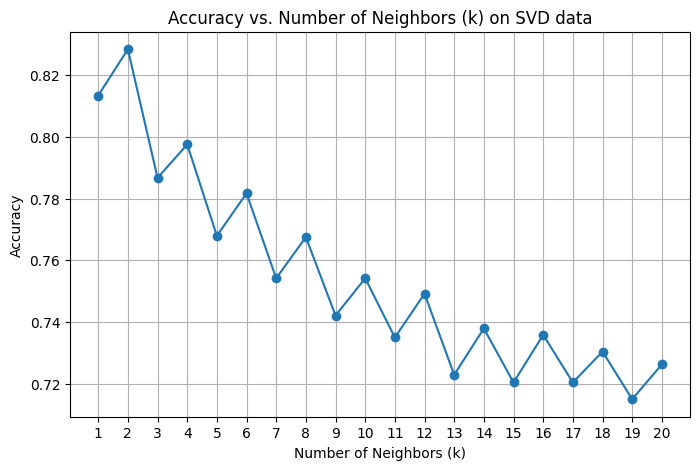

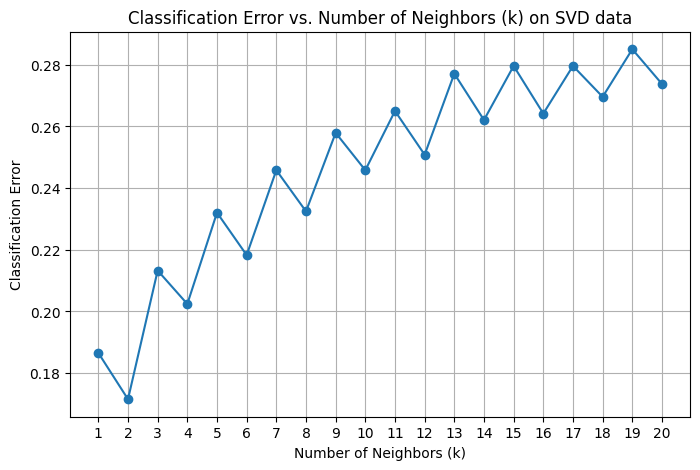

In [27]:
k_values_svd = range(1, 21)
accuracies_svd = []
errors_svd = []

for k in k_values_svd:
    knn_svd = KNeighborsClassifier(n_neighbors=k)
    knn_svd.fit(X_train_svd_smote, y_train_svd_smote)  # Dữ liệu đã SMOTE
    y_pred = knn_svd.predict(X_test_svd)
    acc_svd = accuracy_score(y_test, y_pred)
    accuracies_svd.append(acc_svd)
    errors_svd.append(1 - acc_svd)

# Vẽ biểu đồ Accuracy cho dữ liệu SVD
plt.figure(figsize=(8,5))
plt.plot(k_values_svd, accuracies_svd, marker='o')
plt.title('Accuracy vs. Number of Neighbors (k) on SVD data')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values_svd)
plt.grid(True)
plt.show()

# Vẽ biểu đồ Classification Error cho dữ liệu SVD
plt.figure(figsize=(8,5))
plt.plot(k_values_svd, errors_svd, marker='o')
plt.title('Classification Error vs. Number of Neighbors (k) on SVD data')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Classification Error')
plt.xticks(k_values_svd)
plt.grid(True)
plt.show()


Tie Point PCA

In [28]:

k = 2  # số láng giềng

# Ví dụ với PCA
# Giả sử bạn có biến: X_train_pca_smote, y_train_pca_smote, X_test_pca
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_train_pca_smote)  # Dữ liệu train đã normalize, PCA và SMOTE

distances, indices = nn.kneighbors(X_test_pca)  # Dữ liệu test đã PCA và normalize

tie_points = 0
total_points = len(X_test_pca)

for i, neighbors_idx in enumerate(indices):
    neighbor_labels = y_train_pca_smote.iloc[neighbors_idx].values  # lấy nhãn theo vị trí
    label_counts = Counter(neighbor_labels)
    most_common = label_counts.most_common()

    max_count = most_common[0][1]
    tied_classes = [label for label, count in most_common if count == max_count]

    if len(tied_classes) > 1:
        tie_points += 1
        print(f"Point {i} has tie between classes {tied_classes} with {max_count} votes each.")

print(f"Total points with tie: {tie_points} out of {total_points}")
print(f"Percentage of tie points (PCA): {tie_points / total_points * 100:.2f}%")


Point 0 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 11 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 17 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 29 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 31 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 37 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 49 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 59 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 65 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 68 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 79 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 83 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 84 has tie between classes [np.int64(1), np.int

Tie Point SVD

In [29]:
k = 2  # số láng giềng

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_train_svd_smote)  # Train sau SVD + SMOTE

distances, indices = nn.kneighbors(X_test_svd)  # Test sau SVD

tie_points = 0
total_points = len(X_test_svd)

for i, neighbors_idx in enumerate(indices):
    neighbor_labels = y_train_svd_smote.iloc[neighbors_idx].values
    label_counts = Counter(neighbor_labels)
    most_common = label_counts.most_common()

    max_count = most_common[0][1]
    tied_classes = [label for label, count in most_common if count == max_count]

    if len(tied_classes) > 1:
        tie_points += 1
        print(f"Point {i} has tie between classes {tied_classes} with {max_count} votes each.")

print(f"Total points with tie: {tie_points} out of {total_points}")
print(f"Percentage of tie points (SVD): {tie_points / total_points * 100:.2f}%")


Point 0 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 11 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 17 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 23 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 29 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 31 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 37 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 47 has tie between classes [np.int64(1), np.int64(0)] with 1 votes each.
Point 48 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 49 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 59 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 63 has tie between classes [np.int64(0), np.int64(1)] with 1 votes each.
Point 65 has tie between classes [np.int64(0), np.int

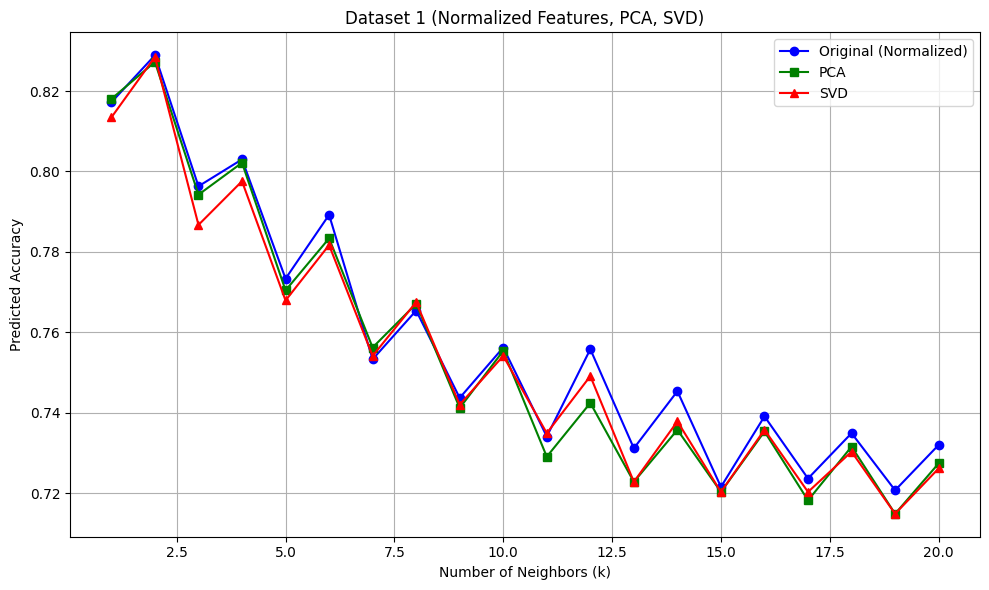

In [30]:
plt.figure(figsize=(10,6))

# Vẽ normalized
plt.plot(k_values, accuracies, label='Original (Normalized)', color='blue', marker='o')

# Vẽ PCA
plt.plot(k_values_pca, accuracies_pca, label='PCA', color='green', marker='s')

# Vẽ SVD
plt.plot(k_values_svd, accuracies_svd, label='SVD', color='red', marker='^')

plt.title('Dataset 1 (Normalized Features, PCA, SVD)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Predicted Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("norm_pca_svd", dpi = 300)

plt.show()


K-Fold

Best k from 5-fold CV: 2 with mean accuracy 0.8342
Test accuracy with best k=2: 0.8272


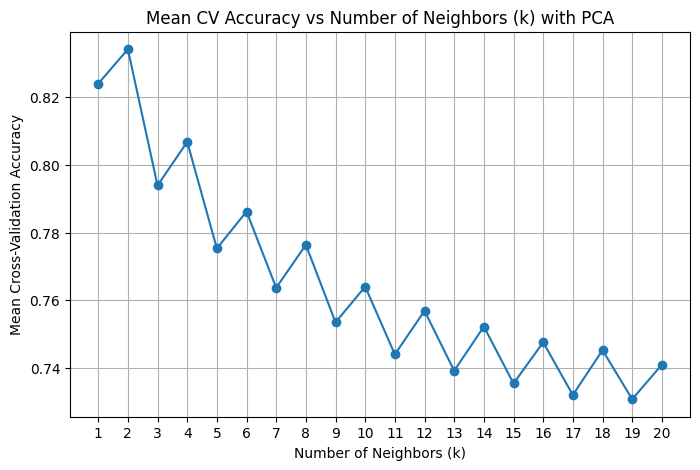

In [31]:

# 1. Chia train-test trước (để đánh giá cuối cùng)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Chuẩn hóa train-test riêng
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 3. Giảm chiều với PCA (fit trên train, transform train và test)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 4. Stratified K-Fold Cross-Validation để chọn k cho KNN
k_values = range(1, 21)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = {k: [] for k in k_values}

for train_index, val_index in skf.split(X_train_pca, y_train):
    X_train_fold, X_val_fold = X_train_pca[train_index], X_train_pca[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # SMOTE trên train fold
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_resampled, y_train_resampled)
        y_pred = knn.predict(X_val_fold)
        acc = accuracy_score(y_val_fold, y_pred)
        cv_accuracies[k].append(acc)

# Tính mean accuracy cho từng k
mean_accuracies = {k: np.mean(acc) for k, acc in cv_accuracies.items()}
best_k = max(mean_accuracies, key=mean_accuracies.get)

print(f"Best k from 5-fold CV: {best_k} with mean accuracy {mean_accuracies[best_k]:.4f}")

# 5. Huấn luyện final model trên toàn bộ train với best k
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_resampled, y_train_resampled)

# 6. Đánh giá trên test set
y_test_pred = knn_final.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy with best k={best_k}: {test_accuracy:.4f}")

# 7. Vẽ biểu đồ mean accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(list(mean_accuracies.keys()), list(mean_accuracies.values()), marker='o')
plt.title('Mean CV Accuracy vs Number of Neighbors (k) with PCA')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(list(mean_accuracies.keys()))
plt.grid(True)
plt.show()



In [32]:
def knn_kfold_cv(X_train, y_train, max_k=20, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = np.zeros(max_k)   # Khởi tạo mảng lưu tổng accuracy cho từng k
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        smote = SMOTE(random_state=42)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
        
        for k in range(1, max_k+1):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_tr_res, y_tr_res)
            y_pred = knn.predict(X_val)
            accuracies[k-1] += accuracy_score(y_val, y_pred)    # Cộng dồn accuracy cho fold này
            
    accuracies /= n_splits  # Tính trung bình accuracy trên tất cả fold
    return accuracies

# 1. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Normalize train and test
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_arr = np.array(y_train)

# 3. PCA and SVD on train data
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svd_full = TruncatedSVD(n_components=X_train_scaled.shape[1], random_state=42)
svd_full.fit(X_train_scaled)
n_comp_95 = (svd_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1
svd = TruncatedSVD(n_components=n_comp_95, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

# 4. Run k-fold CV on train sets for normalized, PCA, SVD
acc_norm = knn_kfold_cv(X_train_scaled, y_train_arr)
acc_pca = knn_kfold_cv(X_train_pca, y_train_arr)
acc_svd = knn_kfold_cv(X_train_svd, y_train_arr)

# 5. Print accuracies
for k in range(1, 21):
    print(f"k={k}: Normalized={acc_norm[k-1]:.4f}, PCA={acc_pca[k-1]:.4f}, SVD={acc_svd[k-1]:.4f}")

best_k_norm = np.argmax(acc_norm) + 1
best_k_pca = np.argmax(acc_pca) + 1
best_k_svd = np.argmax(acc_svd) + 1

for k in range(1, 21):
    print(f"k={k}: Normalized={acc_norm[k-1]:.4f}, PCA={acc_pca[k-1]:.4f}, SVD={acc_svd[k-1]:.4f}")

print("\nBest k choices:")
print(f"Normalized: k = {best_k_norm} with accuracy = {acc_norm[best_k_norm-1]:.4f}")
print(f"PCA: k = {best_k_pca} with accuracy = {acc_pca[best_k_pca-1]:.4f}")
print(f"SVD: k = {best_k_svd} with accuracy = {acc_svd[best_k_svd-1]:.4f}")


k=1: Normalized=0.8215, PCA=0.8240, SVD=0.8258
k=2: Normalized=0.8318, PCA=0.8342, SVD=0.8352
k=3: Normalized=0.7948, PCA=0.7939, SVD=0.8004
k=4: Normalized=0.8075, PCA=0.8068, SVD=0.8100
k=5: Normalized=0.7708, PCA=0.7753, SVD=0.7769
k=6: Normalized=0.7850, PCA=0.7862, SVD=0.7877
k=7: Normalized=0.7601, PCA=0.7637, SVD=0.7624
k=8: Normalized=0.7708, PCA=0.7764, SVD=0.7785
k=9: Normalized=0.7438, PCA=0.7535, SVD=0.7526
k=10: Normalized=0.7572, PCA=0.7640, SVD=0.7678
k=11: Normalized=0.7335, PCA=0.7440, SVD=0.7424
k=12: Normalized=0.7488, PCA=0.7569, SVD=0.7546
k=13: Normalized=0.7301, PCA=0.7392, SVD=0.7369
k=14: Normalized=0.7453, PCA=0.7522, SVD=0.7504
k=15: Normalized=0.7277, PCA=0.7354, SVD=0.7351
k=16: Normalized=0.7419, PCA=0.7476, SVD=0.7483
k=17: Normalized=0.7222, PCA=0.7320, SVD=0.7315
k=18: Normalized=0.7338, PCA=0.7453, SVD=0.7424
k=19: Normalized=0.7195, PCA=0.7308, SVD=0.7284
k=20: Normalized=0.7324, PCA=0.7410, SVD=0.7397
k=1: Normalized=0.8215, PCA=0.8240, SVD=0.8258
k=

In [33]:
test_accuracies_norm = []
test_accuracies_pca = []
test_accuracies_svd = []

smote = SMOTE(random_state=42)

for k in range(1, 21):
    # Normalized
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_arr)
    knn_norm = KNeighborsClassifier(n_neighbors=k)
    knn_norm.fit(X_train_res, y_train_res)
    y_pred_norm = knn_norm.predict(X_test_scaled)
    test_accuracies_norm.append(accuracy_score(y_test, y_pred_norm))
    
    # PCA
    X_train_res_pca, y_train_res_pca = smote.fit_resample(X_train_pca, y_train_arr)
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_res_pca, y_train_res_pca)
    y_pred_pca = knn_pca.predict(X_test_pca)
    test_accuracies_pca.append(accuracy_score(y_test, y_pred_pca))
    
    # SVD
    X_train_res_svd, y_train_res_svd = smote.fit_resample(X_train_svd, y_train_arr)
    knn_svd = KNeighborsClassifier(n_neighbors=k)
    knn_svd.fit(X_train_res_svd, y_train_res_svd)
    y_pred_svd = knn_svd.predict(X_test_svd)
    test_accuracies_svd.append(accuracy_score(y_test, y_pred_svd))

# In test accuracies cho từng k
print("k\tTest Acc Normalized\tTest Acc PCA\tTest Acc SVD")
for k in range(20):
    print(f"{k+1}\t{test_accuracies_norm[k]:.4f}\t\t\t{test_accuracies_pca[k]:.4f}\t\t{test_accuracies_svd[k]:.4f}")


k	Test Acc Normalized	Test Acc PCA	Test Acc SVD
1	0.8172			0.8180		0.8134
2	0.8289			0.8272		0.8285
3	0.7963			0.7942		0.7867
4	0.8030			0.8022		0.7976
5	0.7734			0.7705		0.7679
6	0.7892			0.7834		0.7817
7	0.7533			0.7563		0.7542
8	0.7654			0.7671		0.7675
9	0.7437			0.7412		0.7421
10	0.7563			0.7554		0.7542
11	0.7341			0.7291		0.7350
12	0.7558			0.7425		0.7492
13	0.7312			0.7229		0.7229
14	0.7454			0.7358		0.7379
15	0.7216			0.7204		0.7204
16	0.7391			0.7354		0.7358
17	0.7237			0.7183		0.7204
18	0.7350			0.7316		0.7304
19	0.7208			0.7149		0.7149
20	0.7321			0.7275		0.7262


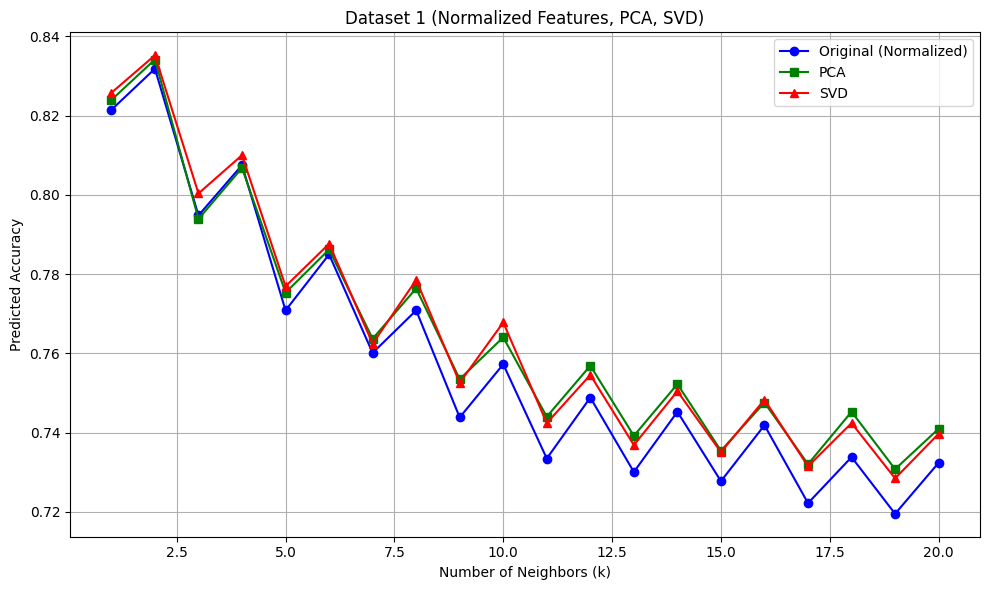

In [34]:
k_values = k_values_pca = k_values_svd = range(1, 21)


plt.figure(figsize=(10,6))

# Vẽ normalized
plt.plot(k_values, acc_norm, label='Original (Normalized)', color='blue', marker='o')

# Vẽ PCA
plt.plot(k_values_pca, acc_pca, label='PCA', color='green', marker='s')

# Vẽ SVD
plt.plot(k_values_svd, acc_svd, label='SVD', color='red', marker='^')

plt.title('Dataset 1 (Normalized Features, PCA, SVD)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Predicted Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("norm_pca_svd_k_fold", dpi = 300)

plt.show()

Tie point when using K-Fold

In [35]:
from collections import Counter
from sklearn.neighbors import NearestNeighbors

def knn_kfold_cv_with_tie(X_train, y_train, max_k=20, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = np.zeros(max_k)
    tie_counts = np.zeros(max_k)
    total_points = 0
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        smote = SMOTE(random_state=42)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
        
        total_points += len(X_val)
        
        for k in range(1, max_k+1):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_tr_res, y_tr_res)
            y_pred = knn.predict(X_val)
            accuracies[k-1] += accuracy_score(y_val, y_pred)
            
            # Tính tie points:
            nn = NearestNeighbors(n_neighbors=k)
            nn.fit(X_tr_res)
            distances, indices = nn.kneighbors(X_val)
            
            for neighbors_idx in indices:
                neighbor_labels = y_tr_res[neighbors_idx]
                label_counts = Counter(neighbor_labels)
                most_common = label_counts.most_common()
                max_count = most_common[0][1]
                tied_classes = [label for label, count in most_common if count == max_count]
                if len(tied_classes) > 1:
                    tie_counts[k-1] += 1
    
    accuracies /= n_splits
    tie_percentages = (tie_counts / total_points) * 100
    
    results = []
    for i in range(max_k):
        results.append({
            'k': i+1,
            'accuracy': accuracies[i],
            'tie_points': tie_counts[i],
            'tie_percentage': tie_percentages[i]
        })
    return results

# Gọi hàm với dữ liệu Normalized, PCA, SVD
results_norm = knn_kfold_cv_with_tie(X_train_scaled, y_train_arr)
results_pca = knn_kfold_cv_with_tie(X_train_pca, y_train_arr)
results_svd = knn_kfold_cv_with_tie(X_train_svd, y_train_arr)

# In header bảng với căn chỉnh đẹp
print(f"{'k':<3} {'Normalized Acc':<15} {'Normalized Tie%':<17} {'PCA Acc':<10} {'PCA Tie%':<10} {'SVD Acc':<10} {'SVD Tie%':<10}")
print("-" * 80)

# In kết quả cho từng k
for i in range(20):
    print(f"{results_norm[i]['k']:<3} "
          f"{results_norm[i]['accuracy']:<15.4f} {results_norm[i]['tie_percentage']:<17.2f} "
          f"{results_pca[i]['accuracy']:<10.4f} {results_pca[i]['tie_percentage']:<10.2f} "
          f"{results_svd[i]['accuracy']:<10.4f} {results_svd[i]['tie_percentage']:<10.2f}")


k   Normalized Acc  Normalized Tie%   PCA Acc    PCA Tie%   SVD Acc    SVD Tie%  
--------------------------------------------------------------------------------
1   0.8215          0.00              0.8240     0.00       0.8258     0.00      
2   0.8318          13.17             0.8342     12.58      0.8352     12.47     
3   0.7948          0.00              0.7939     0.00       0.8004     0.00      
4   0.8075          8.77              0.8068     8.77       0.8100     8.91      
5   0.7708          0.00              0.7753     0.00       0.7769     0.00      
6   0.7850          6.30              0.7862     6.76       0.7877     6.49      
7   0.7601          0.00              0.7637     0.00       0.7624     0.00      
8   0.7708          5.28              0.7764     5.60       0.7785     5.40      
9   0.7438          0.00              0.7535     0.00       0.7526     0.00      
10  0.7572          4.87              0.7640     4.69       0.7678     4.97      
11  0.7335       

Leave-One-Out

In [37]:

loo = LeaveOneOut()
k = 2  # số láng giềng KNN

# Khởi tạo danh sách lưu true/pred cho từng phương pháp
y_true_norm, y_pred_norm = [], []
y_true_pca, y_pred_pca = [], []
y_true_svd, y_pred_svd = [], []

smote = SMOTE(random_state=42)  # Tạo SMOTE 1 lần duy nhất

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 1. Normalize
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_res_norm, y_train_res_norm = smote.fit_resample(X_train_scaled, y_train)
    
    knn_norm = KNeighborsClassifier(n_neighbors=k)
    knn_norm.fit(X_train_res_norm, y_train_res_norm)
    y_pred_sample_norm = knn_norm.predict(X_test_scaled)
    
    y_true_norm.append(y_test.iloc[0])
    y_pred_norm.append(y_pred_sample_norm[0])
    
    # 2. PCA
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    X_train_res_pca, y_train_res_pca = smote.fit_resample(X_train_pca, y_train)
    
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_res_pca, y_train_res_pca)
    y_pred_sample_pca = knn_pca.predict(X_test_pca)
    
    y_true_pca.append(y_test.iloc[0])
    y_pred_pca.append(y_pred_sample_pca[0])
    
    # 3. SVD
    svd_full = TruncatedSVD(n_components=X_train_scaled.shape[1], random_state=42)
    svd_full.fit(X_train_scaled)
    n_comp_95 = (svd_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1
    svd = TruncatedSVD(n_components=n_comp_95, random_state=42)
    
    X_train_svd = svd.fit_transform(X_train_scaled)
    X_test_svd = svd.transform(X_test_scaled)
    
    X_train_res_svd, y_train_res_svd = smote.fit_resample(X_train_svd, y_train)
    
    knn_svd = KNeighborsClassifier(n_neighbors=k)
    knn_svd.fit(X_train_res_svd, y_train_res_svd)
    y_pred_sample_svd = knn_svd.predict(X_test_svd)
    
    y_true_svd.append(y_test.iloc[0])
    y_pred_svd.append(y_pred_sample_svd[0])

# Tính accuracy và classification error cho từng phương pháp
def calc_metrics(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    print(f"{method_name} LOOCV Accuracy with k={k}: {acc:.4f}")
    print(f"{method_name} LOOCV Classification Error with k={k}: {err:.4f}\n")

calc_metrics(y_true_norm, y_pred_norm, "Normalized")
calc_metrics(y_true_pca, y_pred_pca, "PCA")
calc_metrics(y_true_svd, y_pred_svd, "SVD")




Normalized LOOCV Accuracy with k=2: 0.8234
Normalized LOOCV Classification Error with k=2: 0.1766

PCA LOOCV Accuracy with k=2: 0.8247
PCA LOOCV Classification Error with k=2: 0.1753

SVD LOOCV Accuracy with k=2: 0.8217
SVD LOOCV Classification Error with k=2: 0.1783

